In [1]:
from __future__ import print_function
import os

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import random
import pickle

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [7]:
from utils.dataloader_utils import dataloader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="butterfly_anomaly_image_resized/train",
    val_root="butterfly_anomaly_image_resized/val",
    test_root="butterfly_anomaly_image_resized/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3096
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 663
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 665


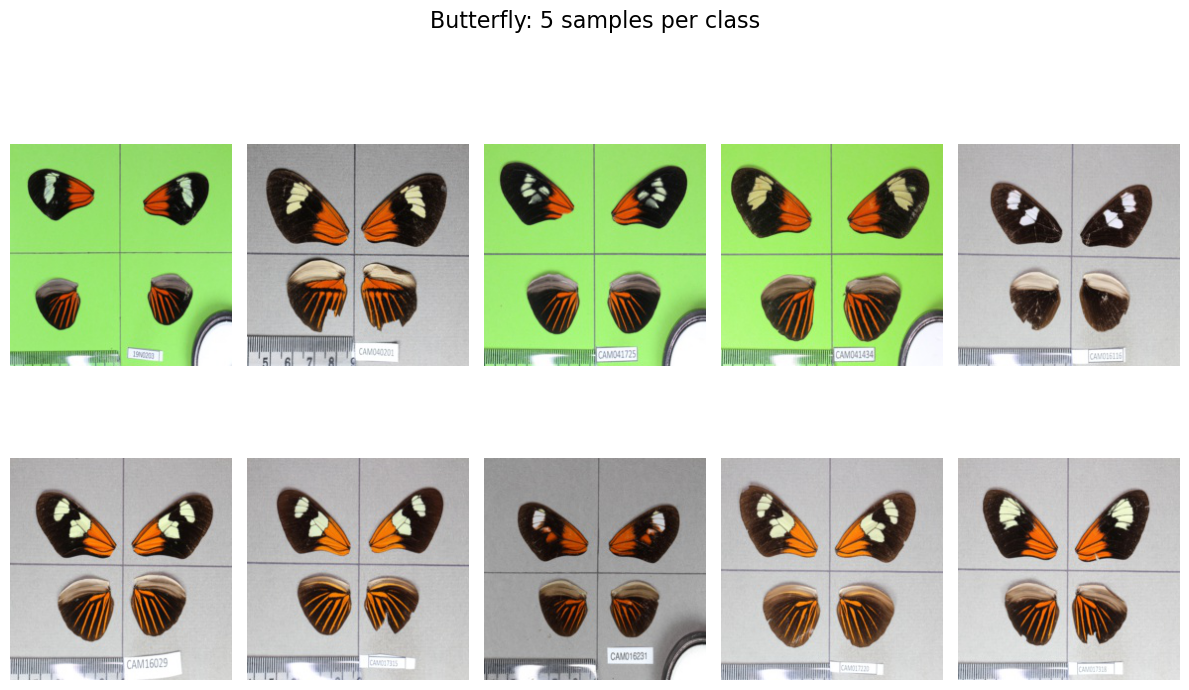

In [8]:
num_classes = len(train_dataset.classes)
fig, axes = plt.subplots(num_classes, 5, figsize=(12, 4 * num_classes), squeeze=False)

# ImageFolder already stores labels in .targets
train_labels = train_dataset.targets

# idx -> class name mapping
idx_to_class = {idx: cls for cls, idx in train_dataset.class_to_idx.items()}

random.seed(42)
for c in range(num_classes):
    class_positions = [pos for pos, y in enumerate(train_labels) if y == c]
    picks = random.sample(class_positions, k=min(5, len(class_positions)))

    for j in range(5):
        ax = axes[c][j]
        ax.axis("off")

        if j < len(picks):
            img, label = train_dataset[picks[j]]
            ax.imshow(img.permute(1, 2, 0).numpy())
            if j == 0:
                ax.set_ylabel(idx_to_class[c], fontsize=11, rotation=0, labelpad=60, va="center")

plt.suptitle("Butterfly: 5 samples per class", fontsize=16)
plt.tight_layout()
plt.show()

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3096
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 663
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 665


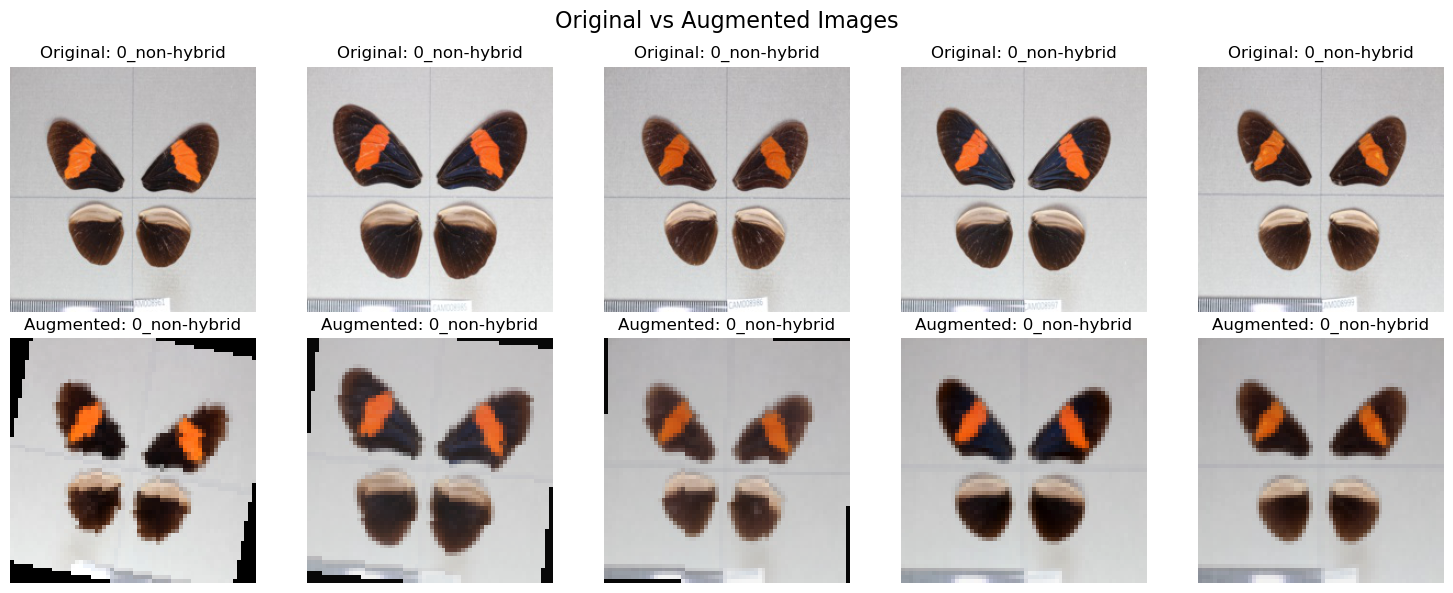

In [10]:
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="butterfly_anomaly_image_resized/train",
    val_root="butterfly_anomaly_image_resized/val",
    test_root="butterfly_anomaly_image_resized/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

# Optional sanity check: class mapping must match across splits
assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

# Display original vs augmented samples
class_names = train_dataset_aug.classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes[0]):
    img, label = train_dataset[i]  # original transform view
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"Original: {class_names[label]}")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img, label = train_dataset_aug[i]  # augmented transform view
    img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img_np)
    ax.set_title(f"Augmented: {class_names[label]}")
    ax.axis("off")

plt.suptitle("Original vs Augmented Images", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3,
                     stride=stride, padding=1, bias=False)

def conv5x5(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=5,
                     stride=stride, padding=2, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        self.conv2 = conv5x5(out_channels, out_channels, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.dropout = nn.Dropout(0.3)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        
        out = self.dropout(self.relu(self.bn1(self.conv1(x))))

        out = self.dropout(self.bn2(self.conv2(out)))

        if self.downsample:
            residual = self.downsample(x)
        
        out = self.relu(out + residual)
        return out

In [12]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=2):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0])
        self.layer2 = self.make_layer(block, 32, layers[1], 2)
        self.layer3 = self.make_layer(block, 64, layers[2], 2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

    def save_checkpoint_append(
        self,
        ckpt_file,
        optimizer=None,
        epoch=None,
        train_loss_history=None,
        val_loss_history=None,
        train_f1_macro_history=None,
        val_f1_macro_history=None,
        train_f1_per_class_history=None,
        val_f1_per_class_history=None,
        train_f2_macro_history=None,
        val_f2_macro_history=None,
        train_f2_per_class_history=None,
        val_f2_per_class_history=None,
        ):
        os.makedirs(os.path.dirname(ckpt_file), exist_ok=True)

        record = {
            "epoch": epoch,
            "model_state_dict": self.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "metrics": {
                "train_loss_history": train_loss_history,
                "val_loss_history": val_loss_history,
                "train_f1_macro_history": train_f1_macro_history,
                "val_f1_macro_history": val_f1_macro_history,
                "train_f1_per_class_history": train_f1_per_class_history.tolist() if hasattr(train_f1_per_class_history, "tolist") else train_f1_per_class_history,
                "val_f1_per_class_history": val_f1_per_class_history.tolist() if hasattr(val_f1_per_class_history, "tolist") else val_f1_per_class_history,
                "train_f2_macro_history": train_f2_macro_history,
                "val_f2_macro_history": val_f2_macro_history,
                "train_f2_per_class_history": train_f2_per_class_history.tolist() if hasattr(train_f2_per_class_history, "tolist") else train_f2_per_class_history,
                "val_f2_per_class_history": val_f2_per_class_history.tolist() if hasattr(val_f2_per_class_history, "tolist") else val_f2_per_class_history
            }
        }

        with open(ckpt_file, "ab") as f:
            pickle.dump(record, f)

    def load_checkpoint_history(self, ckpt_file):
        history = []
        with open(ckpt_file, "rb") as f:
            while True:
                try:
                    history.append(pickle.load(f))
                except EOFError:
                    break
        return history

# Instantiate and verify
model = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)

In [ ]:
import copy
from math import inf
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassFBetaScore

def train_and_evaluate(
    model, 
    train_set, 
    val_set, 
    optimizer, 
    num_epochs, 
    batch_size, 
    class_weights_val, 
    ckpt_file, 
    num_workers=4, 
    patience=6,
    min_delta=1e-3,
    early_stop_metric="val_f2_class1",
    restore_best_weights=True):

    _, _, _, train_loader, val_loader, _ = dataloader(
        train_set=train_set,
        val_set=val_set,
        batch_size=batch_size,
        num_workers=num_workers
    )

    train_loss_list = []
    val_loss_list = []
    train_f1_macro_list = []
    val_f1_macro_list = []
    train_f1_per_class_list = []
    val_f1_per_class_list = []
    train_f2_macro_list = []
    val_f2_macro_list = []
    train_f2_per_class_list = []
    val_f2_per_class_list = []
    
    hybrid_idx = train_set.class_to_idx["1_hybrid"]
    class_weights = torch.ones(len(train_set.classes), device=device)
    class_weights[hybrid_idx] = class_weights_val

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion_show = nn.CrossEntropyLoss()

    train_f1_macro_metric = MulticlassF1Score(num_classes=2, average="macro").to(device)
    train_f1_per_class_metric = MulticlassF1Score(num_classes=2, average=None).to(device)
    val_f1_macro_metric = MulticlassF1Score(num_classes=2, average="macro").to(device)
    val_f1_per_class_metric = MulticlassF1Score(num_classes=2, average=None).to(device)

    train_f2_macro_metric = MulticlassFBetaScore(num_classes=2, average="macro", beta=2).to(device)
    train_f2_per_class_metric = MulticlassFBetaScore(num_classes=2, average=None, beta=2).to(device)
    val_f2_macro_metric = MulticlassFBetaScore(num_classes=2, average="macro", beta=2).to(device)
    val_f2_per_class_metric = MulticlassFBetaScore(num_classes=2, average=None, beta=2).to(device)

    best_score = -inf
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss_show = criterion_show(outputs, labels)
            loss.backward() 
            optimizer.step()

            epoch_train_loss += loss_show.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        model.eval()
        train_f1_macro_metric.reset()
        train_f1_per_class_metric.reset()
        train_f2_macro_metric.reset()
        train_f2_per_class_metric.reset()

        with torch.no_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)

                train_f1_macro_metric.update(preds, labels)
                train_f1_per_class_metric.update(preds, labels)
                train_f2_macro_metric.update(preds, labels)
                train_f2_per_class_metric.update(preds, labels)

        train_f1_macro_list.append(train_f1_macro_metric.compute().item())
        train_f1_per_class_list.append(train_f1_per_class_metric.compute().cpu().detach().numpy())
        train_f2_macro_list.append(train_f2_macro_metric.compute().item())
        train_f2_per_class_list.append(train_f2_per_class_metric.compute().cpu().detach().numpy())

        epoch_val_loss = 0.0
        val_f1_macro_metric.reset()
        val_f1_per_class_metric.reset()
        val_f2_macro_metric.reset()
        val_f2_per_class_metric.reset()

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion_show(outputs, labels)
                epoch_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_f1_macro_metric.update(predicted, labels)
                val_f1_per_class_metric.update(predicted, labels)
                val_f2_macro_metric.update(predicted, labels)
                val_f2_per_class_metric.update(predicted, labels)

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)
        val_f1_macro_list.append(val_f1_macro_metric.compute().item())
        val_f1_per_class_list.append(val_f1_per_class_metric.compute().cpu().detach().numpy())
        val_f2_macro_list.append(val_f2_macro_metric.compute().item())
        val_f2_per_class_list.append(val_f2_per_class_metric.compute().cpu().detach().numpy())

        model.save_checkpoint_append(
            ckpt_file=ckpt_file,
            optimizer=optimizer,
            epoch=epoch + 1,
            train_loss_history=train_loss_list,
            val_loss_history=val_loss_list,
            train_f1_macro_history=train_f1_macro_list,
            val_f1_macro_history=val_f1_macro_list,
            train_f1_per_class_history=train_f1_per_class_list,
            val_f1_per_class_history=val_f1_per_class_list
        )

        if early_stop_metric == "val_f2_class1":
            current_score = val_f2_per_class_list[-1][1]  # F2 for class 1 (hybrid)
        elif early_stop_metric == "val_f2_macro":
            current_score = val_f2_macro_list[-1]
        elif early_stop_metric == "val_loss":
            current_score = -avg_val_loss  # negative so higher is better
        else:
            current_score = val_f2_per_class_list[-1][1]

        if current_score > best_score + min_delta:
            best_score = current_score
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"  [Epoch {epoch+1}] Improvement! New best score: {current_score:.6f}")
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], "
                f"Train Loss: {avg_train_loss:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}, "
                f"Train F1-Macro: {train_f1_macro_list[-1]:.4f}, "
                f"Val F1-Macro: {val_f1_macro_list[-1]:.4f}, "
                f"Train F1-Per-Class: {train_f1_per_class_list[-1]}, "
                f"Val F1-Per-Class: {val_f1_per_class_list[-1]}, "
                f"Train F2-Macro: {train_f2_macro_list[-1]:.4f}, "
                f"Val F2-Macro: {val_f2_macro_list[-1]:.4f}, "
                f"Train F2-Per-Class: {train_f2_per_class_list[-1]}, "
                f"Val F2-Per-Class: {val_f2_per_class_list[-1]}, "
                f"No improvement: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. "
                  f"No improvement for {patience} epochs.")
            break

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], "
                  f"Epoch [{epoch+1}/{num_epochs}], "
                f"Train Loss: {avg_train_loss:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}, "
                f"Train F1-Macro: {train_f1_macro_list[-1]:.4f}, "
                f"Val F1-Macro: {val_f1_macro_list[-1]:.4f}, "
                f"Train F1-Per-Class: {train_f1_per_class_list[-1]}, "
                f"Val F1-Per-Class: {val_f1_per_class_list[-1]}",
                f"Train F2-Macro: {train_f2_macro_list[-1]:.4f}, "
                f"Val F2-Macro: {val_f2_macro_list[-1]:.4f}, "
                f"Train F2-Per-Class: {train_f2_per_class_list[-1]}, "
                f"Val F2-Per-Class: {val_f2_per_class_list[-1]}")
            
    if restore_best_weights and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored model weights from best epoch (score: {best_score:.6f})")

    return (
        train_loss_list,
        val_loss_list,
        train_f1_macro_list,
        val_f1_macro_list,
        train_f1_per_class_list,
        val_f1_per_class_list,
        train_f2_macro_list,
        val_f2_macro_list,
        train_f2_per_class_list,
        val_f2_per_class_list
    )

In [15]:
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassFBetaScore

def evaluate_split(model, dataset, batch_size, criterion, num_workers=4):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    f1_macro = MulticlassF1Score(num_classes=2, average="macro").to(device)
    f1_per_class = MulticlassF1Score(num_classes=2, average=None).to(device)
    f2_macro = MulticlassFBetaScore(num_classes=2, average="macro", beta=2).to(device)
    f2_per_class = MulticlassFBetaScore(num_classes=2, average=None, beta=2).to(device)

    model.eval()
    total_loss = 0.0
    f1_macro.reset()
    f1_per_class.reset()
    f2_macro.reset()
    f2_per_class.reset()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            f1_macro.update(preds, labels)
            f1_per_class.update(preds, labels)
            f2_macro.update(preds, labels)
            f2_per_class.update(preds, labels)

    return {
        "loss": total_loss / len(loader),
        "f1_macro": f1_macro.compute().item(),
        "f1_per_class": f1_per_class.compute().cpu().numpy(),
        "f2_macro": f2_macro.compute().item(),
        "f2_per_class": f2_per_class.compute().cpu().numpy()
    }

In [16]:
model_resnet_a = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a = optim.Adam(model_resnet_a.parameters(), lr=0.001, weight_decay=1e-4)

print("\nTraining Model A (with augmentation)...")
results_a = train_and_evaluate(model_resnet_a, train_dataset_aug, val_dataset, optimizer_a, num_epochs=30, batch_size=32, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_1.pkl")


Training Model A (with augmentation)...


ValueError: too many values to unpack (expected 3)

In [23]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_1.pkl"
hist = model_resnet_a.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 17
Best val F1(class 1): 0.9082125425338745


In [13]:

best_model = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)

# move checkpoint tensors to current device (safe across CPU/GPU)
state_dict = {
    k: (v.to(device) if torch.is_tensor(v) else v)
    for k, v in best["model_state_dict"].items()
}
best_model.load_state_dict(state_dict)
best_model.eval()

# 4) Evaluate on test split
criterion = nn.CrossEntropyLoss()
test_metrics = evaluate_split(
    model=best_model,
    dataset=test_dataset,
    batch_size=32,
    criterion=criterion,
    num_workers=2
)

print("Test loss:", test_metrics["loss"])
print("Test F1 macro:", test_metrics["f1_macro"])
print("Test F1 per class:", test_metrics["f1_per_class"])
print(f"Test F1 for class 1 ({idx_to_class[1]}):", float(test_metrics["f1_per_class"][1]))

Test loss: 0.07154428953002762
Test F1 macro: 0.9590027332305908
Test F1 per class: [0.98649865 0.9315069 ]
Test F1 for class 1 (1_hybrid): 0.931506872177124


In [24]:
model_resnet_a = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a2 = optim.Adam(model_resnet_a.parameters(), lr=0.001, weight_decay=1e-4)

print("\nTraining Model A (with augmentation)...")
results_a2 = train_and_evaluate(model_resnet_a, train_dataset_aug, val_dataset, optimizer_a2, num_epochs=30, batch_size=32, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_2.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.604938
  [Epoch 2] Improvement! New best score: 0.618297
Epoch [5/30], Train Loss: 0.2631, Val Loss: 0.4253, Train F1-Macro: 0.4571, Val F1-Macro: 0.4831, Train F1-Per-Class: [0.91021127 0.00390625], Val F1-Per-Class: [0.91268533 0.05357143], No improvement: 3/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2631, Val Loss: 0.4253, Train F1-Macro: 0.4571, Val F1-Macro: 0.4831, Train F1-Per-Class: [0.91021127 0.00390625], Val F1-Per-Class: [0.91268533 0.05357143]
  [Epoch 8] Improvement! New best score: 0.894231
Epoch [10/30], Train Loss: 0.1672, Val Loss: 0.2070, Train F1-Macro: 0.8907, Val F1-Macro: 0.8497, Train F1-Per-Class: [0.9598417 0.82146  ], Val F1-Per-Class: [0.9408451 0.7586207], No improvement: 2/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1672, Val Loss: 0.2070, Train F1-Macro: 0.8907, Val F1-Macro: 0.8497, Train F1-Per-Class: [0.9598417 0.82146  ], Val F1-Per-Class: [0.9408451 0.7586207]
  [E

In [25]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_2.pkl"
hist = model_resnet_a.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 13
Best val F1(class 1): 0.900473952293396


In [26]:
model_resnet_a3 = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a3 = optim.Adam(model_resnet_a3.parameters(), lr=0.001, weight_decay=1e-4)

print("\nTraining Model A (with augmentation)...")
results_a3 = train_and_evaluate(model_resnet_a3, train_dataset_aug, val_dataset, optimizer_a3, num_epochs=30, batch_size=32, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_3.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.310160
  [Epoch 2] Improvement! New best score: 0.630824
  [Epoch 3] Improvement! New best score: 0.641026
Epoch [5/30], Train Loss: 0.2869, Val Loss: 0.4403, Train F1-Macro: 0.7315, Val F1-Macro: 0.7422, Train F1-Per-Class: [0.8606325  0.60236466], Val F1-Per-Class: [0.8728729 0.6116208], No improvement: 2/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2869, Val Loss: 0.4403, Train F1-Macro: 0.7315, Val F1-Macro: 0.7422, Train F1-Per-Class: [0.8606325  0.60236466], Val F1-Per-Class: [0.8728729 0.6116208]
  [Epoch 6] Improvement! New best score: 0.771930
  [Epoch 8] Improvement! New best score: 0.803571
  [Epoch 10] Improvement! New best score: 0.843478
Epoch [10/30], Train Loss: 0.2061, Val Loss: 0.1765, Train F1-Macro: 0.8517, Val F1-Macro: 0.9053, Train F1-Per-Class: [0.9411765  0.76221496], Val F1-Per-Class: [0.9671533  0.84347826], No improvement: 0/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.2061, 

In [27]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_3.pkl"
hist = model_resnet_a3.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 16
Best val F1(class 1): 0.8949771523475647


In [28]:
model_resnet_a4 = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a4 = optim.Adam(model_resnet_a4.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a4 = train_and_evaluate(model_resnet_a4, train_dataset_aug, val_dataset, optimizer_a4, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_4.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.541237
  [Epoch 2] Improvement! New best score: 0.635451
  [Epoch 5] Improvement! New best score: 0.837209
Epoch [5/30], Train Loss: 0.2523, Val Loss: 0.2243, Train F1-Macro: 0.8887, Val F1-Macro: 0.9029, Train F1-Per-Class: [0.962517   0.81495684], Val F1-Per-Class: [0.96849686 0.8372093 ], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2523, Val Loss: 0.2243, Train F1-Macro: 0.8887, Val F1-Macro: 0.9029, Train F1-Per-Class: [0.962517   0.81495684], Val F1-Per-Class: [0.96849686 0.8372093 ]
  [Epoch 8] Improvement! New best score: 0.873874
Epoch [10/30], Train Loss: 0.1884, Val Loss: 0.1847, Train F1-Macro: 0.8632, Val F1-Macro: 0.8731, Train F1-Per-Class: [0.9450283 0.7813505], Val F1-Per-Class: [0.952734   0.79352224], No improvement: 2/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1884, Val Loss: 0.1847, Train F1-Macro: 0.8632, Val F1-Macro: 0.8731, Train F1-Per-Class: [0.9450283 0.78

In [29]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_4.pkl"
hist = model_resnet_a4.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 12
Best val F1(class 1): 0.8837209343910217


In [30]:
model_resnet_a5 = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a5 = optim.Adam(model_resnet_a5.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a5 = train_and_evaluate(model_resnet_a5, train_dataset_aug, val_dataset, optimizer_a5, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_5.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.109375
  [Epoch 2] Improvement! New best score: 0.622951
  [Epoch 4] Improvement! New best score: 0.705426
Epoch [5/30], Train Loss: 0.2647, Val Loss: 0.2868, Train F1-Macro: 0.7786, Val F1-Macro: 0.8073, Train F1-Per-Class: [0.8940777 0.6630655], Val F1-Per-Class: [0.9174664 0.6971831], No improvement: 1/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2647, Val Loss: 0.2868, Train F1-Macro: 0.7786, Val F1-Macro: 0.8073, Train F1-Per-Class: [0.8940777 0.6630655], Val F1-Per-Class: [0.9174664 0.6971831]
  [Epoch 9] Improvement! New best score: 0.843750
Epoch [10/30], Train Loss: 0.1710, Val Loss: 0.2697, Train F1-Macro: 0.8425, Val F1-Macro: 0.8270, Train F1-Per-Class: [0.935123  0.7498039], Val F1-Per-Class: [0.9300567 0.7238806], No improvement: 1/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1710, Val Loss: 0.2697, Train F1-Macro: 0.8425, Val F1-Macro: 0.8270, Train F1-Per-Class: [0.935123  0.7498039], Va

In [31]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_5.pkl"
hist = model_resnet_a5.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 12
Best val F1(class 1): 0.8663594722747803


In [32]:
model_resnet_a6 = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a6 = optim.Adam(model_resnet_a6.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a6 = train_and_evaluate(model_resnet_a6, train_dataset_aug, val_dataset, optimizer_a6, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_6.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 2] Improvement! New best score: 0.120690
  [Epoch 3] Improvement! New best score: 0.429980
  [Epoch 4] Improvement! New best score: 0.551913
Epoch [5/30], Train Loss: 0.2647, Val Loss: 0.3679, Train F1-Macro: 0.6583, Val F1-Macro: 0.6665, Train F1-Per-Class: [0.92980564 0.38679245], Val F1-Per-Class: [0.9300758 0.4028777], No improvement: 1/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2647, Val Loss: 0.3679, Train F1-Macro: 0.6583, Val F1-Macro: 0.6665, Train F1-Per-Class: [0.92980564 0.38679245], Val F1-Per-Class: [0.9300758 0.4028777]
  [Epoch 6] Improvement! New best score: 0.621538
  [Epoch 7] Improvement! New best score: 0.883721
  [Epoch 8] Improvement! New best score: 0.885572
Epoch [10/30], Train Loss: 0.1526, Val Loss: 0.1552, Train F1-Macro: 0.9085, Val F1-Macro: 0.8976, Train F1-Per-Class: [0.96662056 0.85031   ], Val F1-Per-Class: [0.9632353 0.8319328], No improvement: 2/6
Epo

In [33]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_6.pkl"
hist = model_resnet_a6.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 14
Best val F1(class 1): 0.9166666865348816


In [34]:
model_resnet_a7 = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a7 = optim.Adam(model_resnet_a7.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a7 = train_and_evaluate(model_resnet_a7, train_dataset_aug, val_dataset, optimizer_a7, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_7.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.632727
  [Epoch 2] Improvement! New best score: 0.729064
  [Epoch 5] Improvement! New best score: 0.760000
Epoch [5/30], Train Loss: 0.2222, Val Loss: 0.2104, Train F1-Macro: 0.8561, Val F1-Macro: 0.8521, Train F1-Per-Class: [0.9435403  0.76872426], Val F1-Per-Class: [0.94423795 0.76      ], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2222, Val Loss: 0.2104, Train F1-Macro: 0.8561, Val F1-Macro: 0.8521, Train F1-Per-Class: [0.9435403  0.76872426], Val F1-Per-Class: [0.94423795 0.76      ]
  [Epoch 8] Improvement! New best score: 0.844828
  [Epoch 9] Improvement! New best score: 0.852321
Epoch [10/30], Train Loss: 0.1432, Val Loss: 0.2673, Train F1-Macro: 0.7527, Val F1-Macro: 0.8023, Train F1-Per-Class: [0.9426379 0.5626741], Val F1-Per-Class: [0.9499136 0.6547619], No improvement: 1/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1432, Val Loss: 0.2673, Train F1-Macro: 0.7527, Val F1-Ma

In [35]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_7.pkl"
hist = model_resnet_a7.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 14
Best val F1(class 1): 0.9026548862457275


In [36]:
model_resnet_a8 = ResNet(ResidualBlock, [3, 2, 2], num_classes=2).to(device)
optimizer_a8 = optim.Adam(model_resnet_a8.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a8 = train_and_evaluate(model_resnet_a8, train_dataset_aug, val_dataset, optimizer_a8, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_8.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.559557
  [Epoch 2] Improvement! New best score: 0.645914
Epoch [5/30], Train Loss: 0.2745, Val Loss: 0.7855, Train F1-Macro: 0.6628, Val F1-Macro: 0.6905, Train F1-Per-Class: [0.79272556 0.5328429 ], Val F1-Per-Class: [0.8240253 0.5570292], No improvement: 3/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2745, Val Loss: 0.7855, Train F1-Macro: 0.6628, Val F1-Macro: 0.6905, Train F1-Per-Class: [0.79272556 0.5328429 ], Val F1-Per-Class: [0.8240253 0.5570292]
  [Epoch 8] Improvement! New best score: 0.712230
  [Epoch 10] Improvement! New best score: 0.784615
Epoch [10/30], Train Loss: 0.1666, Val Loss: 0.2023, Train F1-Macro: 0.8690, Val F1-Macro: 0.8660, Train F1-Per-Class: [0.94721943 0.7906977 ], Val F1-Per-Class: [0.94746715 0.7846154 ], No improvement: 0/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1666, Val Loss: 0.2023, Train F1-Macro: 0.8690, Val F1-Macro: 0.8660, Train F1-Per-Class: [0.94721943 0.79

In [37]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_8.pkl"
hist = model_resnet_a8.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 14
Best val F1(class 1): 0.9174311757087708


In [38]:
model_resnet_a9 = ResNet(ResidualBlock, [2, 3, 2], num_classes=2).to(device)
optimizer_a9 = optim.Adam(model_resnet_a9.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a9 = train_and_evaluate(model_resnet_a9, train_dataset_aug, val_dataset, optimizer_a9, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_9.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.096000
  [Epoch 2] Improvement! New best score: 0.631229
  [Epoch 5] Improvement! New best score: 0.744186
Epoch [5/30], Train Loss: 0.2707, Val Loss: 0.2461, Train F1-Macro: 0.8397, Val F1-Macro: 0.8412, Train F1-Per-Class: [0.9357835 0.7435484], Val F1-Per-Class: [0.93820226 0.74418604], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2707, Val Loss: 0.2461, Train F1-Macro: 0.8397, Val F1-Macro: 0.8412, Train F1-Per-Class: [0.9357835 0.7435484], Val F1-Per-Class: [0.93820226 0.74418604]
  [Epoch 8] Improvement! New best score: 0.879227
Epoch [10/30], Train Loss: 0.1389, Val Loss: 0.2355, Train F1-Macro: 0.8428, Val F1-Macro: 0.8438, Train F1-Per-Class: [0.9339603 0.7517294], Val F1-Per-Class: [0.9366131  0.75092936], No improvement: 2/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1389, Val Loss: 0.2355, Train F1-Macro: 0.8428, Val F1-Macro: 0.8438, Train F1-Per-Class: [0.9339603 0.751729

In [40]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_9.pkl"
hist = model_resnet_a9.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 11
Best val F1(class 1): 0.9209302067756653


In [41]:
model_resnet_a10 = ResNet(ResidualBlock, [2, 2, 3], num_classes=2).to(device)
optimizer_a10 = optim.Adam(model_resnet_a10.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a10 = train_and_evaluate(model_resnet_a10, train_dataset_aug, val_dataset, optimizer_a10, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_10.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.610063
  [Epoch 5] Improvement! New best score: 0.774869
Epoch [5/30], Train Loss: 0.2364, Val Loss: 0.2631, Train F1-Macro: 0.8518, Val F1-Macro: 0.8685, Train F1-Per-Class: [0.95849764 0.74509805], Val F1-Per-Class: [0.9621145 0.7748691], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2364, Val Loss: 0.2631, Train F1-Macro: 0.8518, Val F1-Macro: 0.8685, Train F1-Per-Class: [0.95849764 0.74509805], Val F1-Per-Class: [0.9621145 0.7748691]
  [Epoch 6] Improvement! New best score: 0.859813
Epoch [10/30], Train Loss: 0.1648, Val Loss: 0.1530, Train F1-Macro: 0.9238, Val F1-Macro: 0.9109, Train F1-Per-Class: [0.9762816 0.8713693], Val F1-Per-Class: [0.9734042 0.8484849], No improvement: 4/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1648, Val Loss: 0.1530, Train F1-Macro: 0.9238, Val F1-Macro: 0.9109, Train F1-Per-Class: [0.9762816 0.8713693], Val F1-Per-Class: [0.9734042 0.8484849]

Early s

In [42]:
print("class_to_idx:", train_dataset_aug.class_to_idx)

ckpt_file = "saved_models/resnet_model_a_log_10.pkl"
hist = model_resnet_a10.load_checkpoint_history(ckpt_file)

# Pick best by validation F1 of class 1
valid = [
r for r in hist
if r.get("metrics", {}).get("val_f1_per_class_history")
and len(r["metrics"]["val_f1_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f1_per_class_history"][-1][1])
)

print("Selected epoch:", best["epoch"])
print("Best val F1(class 1):", float(best["metrics"]["val_f1_per_class_history"][-1][1]))

class_to_idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Selected epoch: 6
Best val F1(class 1): 0.8598130941390991


In [43]:
model_resnet_a11 = ResNet(ResidualBlock, [3, 3, 2], num_classes=2).to(device)
optimizer_a11 = optim.Adam(model_resnet_a11.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a11 = train_and_evaluate(model_resnet_a11, train_dataset_aug, val_dataset, optimizer_a11, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_11.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 3] Improvement! New best score: 0.220472
Epoch [5/30], Train Loss: 0.2790, Val Loss: 0.5038, Train F1-Macro: 0.5284, Val F1-Macro: 0.5498, Train F1-Per-Class: [0.9157652  0.14104882], Val F1-Per-Class: [0.9178423  0.18181819], No improvement: 2/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2790, Val Loss: 0.5038, Train F1-Macro: 0.5284, Val F1-Macro: 0.5498, Train F1-Per-Class: [0.9157652  0.14104882], Val F1-Per-Class: [0.9178423  0.18181819]
  [Epoch 7] Improvement! New best score: 0.752941
  [Epoch 8] Improvement! New best score: 0.802030
  [Epoch 10] Improvement! New best score: 0.851852
Epoch [10/30], Train Loss: 0.1746, Val Loss: 0.1354, Train F1-Macro: 0.9291, Val F1-Macro: 0.9115, Train F1-Per-Class: [0.97561926 0.8826291 ], Val F1-Per-Class: [0.9711712 0.8518519], No improvement: 0/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1746, Val Loss: 0.1354, Train F1-Macro: 0.9291, Val F1

In [44]:
model_resnet_a12 = ResNet(ResidualBlock, [3, 2, 3], num_classes=2).to(device)
optimizer_a12 = optim.Adam(model_resnet_a12.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a12 = train_and_evaluate(model_resnet_a12, train_dataset_aug, val_dataset, optimizer_a12, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_12.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.434783
  [Epoch 2] Improvement! New best score: 0.645914
  [Epoch 4] Improvement! New best score: 0.659091
  [Epoch 5] Improvement! New best score: 0.807175
Epoch [5/30], Train Loss: 0.2376, Val Loss: 0.2093, Train F1-Macro: 0.8901, Val F1-Macro: 0.8841, Train F1-Per-Class: [0.962891   0.81722486], Val F1-Per-Class: [0.9610154  0.80717486], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2376, Val Loss: 0.2093, Train F1-Macro: 0.8901, Val F1-Macro: 0.8841, Train F1-Per-Class: [0.962891   0.81722486], Val F1-Per-Class: [0.9610154  0.80717486]
  [Epoch 10] Improvement! New best score: 0.817204
Epoch [10/30], Train Loss: 0.1787, Val Loss: 0.1641, Train F1-Macro: 0.9076, Val F1-Macro: 0.8937, Train F1-Per-Class: [0.9727169  0.84245074], Val F1-Per-Class: [0.97017545 0.8172043 ], No improvement: 0/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1787, Val Loss: 0.1641, Train F1-Macro: 0.9076, Val 

In [45]:
model_resnet_a13 = ResNet(ResidualBlock, [3, 3, 3], num_classes=2).to(device)
optimizer_a13 = optim.Adam(model_resnet_a13.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a13 = train_and_evaluate(model_resnet_a13, train_dataset_aug, val_dataset, optimizer_a13, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_13.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.601824
  [Epoch 2] Improvement! New best score: 0.632588
  [Epoch 4] Improvement! New best score: 0.698529
  [Epoch 5] Improvement! New best score: 0.722628
Epoch [5/30], Train Loss: 0.2517, Val Loss: 0.2349, Train F1-Macro: 0.8439, Val F1-Macro: 0.8252, Train F1-Per-Class: [0.93601465 0.75177306], Val F1-Per-Class: [0.92775667 0.72262776], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2517, Val Loss: 0.2349, Train F1-Macro: 0.8439, Val F1-Macro: 0.8252, Train F1-Per-Class: [0.93601465 0.75177306], Val F1-Per-Class: [0.92775667 0.72262776]
  [Epoch 7] Improvement! New best score: 0.858447
Epoch [10/30], Train Loss: 0.1488, Val Loss: 2.1400, Train F1-Macro: 0.5161, Val F1-Macro: 0.5166, Train F1-Per-Class: [0.61694735 0.4153407 ], Val F1-Per-Class: [0.619403   0.41379312], No improvement: 3/6
Epoch [10/30], Epoch [10/30], Train Loss: 0.1488, Val Loss: 2.1400, Train F1-Macro: 0.5161, Val F

In [46]:
model_resnet_a14 = ResNet(ResidualBlock, [4, 3, 3], num_classes=2).to(device)
optimizer_a14 = optim.Adam(model_resnet_a14.parameters(), lr=0.001, weight_decay=1e-6)

print("\nTraining Model A (with augmentation)...")
results_a14 = train_and_evaluate(model_resnet_a14, train_dataset_aug, val_dataset, optimizer_a14, num_epochs=30, batch_size=64, class_weights_val=3.5, ckpt_file="saved_models/resnet_model_a_log_14.pkl")


Training Model A (with augmentation)...
  [Epoch 1] Improvement! New best score: 0.626263
Epoch [5/30], Train Loss: 0.2499, Val Loss: 0.5102, Train F1-Macro: 0.7307, Val F1-Macro: 0.7277, Train F1-Per-Class: [0.8574566  0.60402685], Val F1-Per-Class: [0.85830784 0.59710145], No improvement: 4/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.2499, Val Loss: 0.5102, Train F1-Macro: 0.7307, Val F1-Macro: 0.7277, Train F1-Per-Class: [0.8574566  0.60402685], Val F1-Per-Class: [0.85830784 0.59710145]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.626263)
